In [ ]:
# 1) Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 2) Load the dataset
df = pd.read_csv('/content/global_sports_footwear_sales_2018_2026.csv')

In [ ]:
# 3) Preview the dataset
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [ ]:
# 4) Check Dataset Shape
df.shape

(30000, 18)

In [ ]:
# 5) Inspect Data Types & Null Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

In [ ]:
# 6) Convert Date Column to Datetime
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
# 7) Verify datatypes
df.dtypes

,0
order_id,object
order_date,datetime64[ns]
brand,object
model_name,object
category,object
gender,object
size,int64
color,object
base_price_usd,int64
discount_percent,int64


In [ ]:
# 8) Generate Summary Statistics (Numerical)
df.describe()

,order_date,size,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,customer_rating
count,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2022-06-28 06:41:02.400000256,8.500867,139.634633,13.332167,121.029035,2.500200,302.714948,4.001543
min,2018-01-01 00:00:00,6.000000,60.000000,0.000000,42.000000,1.000000,42.000000,3.000000
25%,2020-04-02 00:00:00,7.000000,100.000000,5.000000,85.000000,1.000000,156.750000,3.500000
50%,2022-06-25 00:00:00,9.000000,140.000000,10.000000,119.200000,3.000000,268.200000,4.000000
75%,2024-09-30 00:00:00,10.000000,180.000000,20.000000,153.600000,4.000000,414.000000,4.500000
max,2026-12-31 00:00:00,11.000000,219.000000,30.000000,219.000000,4.000000,876.000000,5.000000
std,NaN,1.710896,46.062549,9.864198,42.511586,1.121149,179.149272,0.577546


In [ ]:
# 9) Summary Statistics (Categorical)
df.describe(include='object')

,order_id,brand,model_name,category,gender,color,payment_method,sales_channel,country,customer_income_level
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,30000,6,899,5,3,5,4,2,6,3
top,ORD129983,ASICS,Model-863,Basketball,Men,Grey,Bank Transfer,Retail Store,UAE,High
freq,1,5132,53,6074,10075,6046,7686,15009,5118,10059


In [ ]:
# 10) Check for Missing Values Explicitly
df.isnull().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [ ]:
# 11) Feature Engineering – Extract Time Components
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter

# Year-wise Revenue Trend
yearly_revenue = df.groupby('year')['revenue_usd'].sum()
yearly_revenue

# Year-wise Units Sold
yearly_units = df.groupby('year')['units_sold'].sum()
yearly_units

# Quarter-wise Revenue
quarterly_revenue = df.groupby('quarter')['revenue_usd'].sum()


,revenue_usd
quarter,
1,2222022.75
2,2279710.45
3,2290468.90
4,2289246.35


In [ ]:
# 12) Revenue Validation
df['calculated_revenue'] = df['final_price_usd'] * df['units_sold']

np.allclose(
    df['calculated_revenue'],
    df['revenue_usd'],
    rtol=1e-05
)


True

In [ ]:
# 13) Drop Temporary Column (Cleanup)
df.drop(columns=['calculated_revenue'], inplace=True)

In [ ]:
# 14) Analyze Categorical Distributions
df['brand'].value_counts()
df['category'].value_counts()
df['sales_channel'].value_counts()
df['country'].value_counts()

,count
country,
UAE,5118
UK,5058
USA,5027
India,4991
Germany,4965
Pakistan,4841


In [ ]:
# 15) Analyze Numerical Distributions
df[['base_price_usd', 'final_price_usd', 'units_sold', 'revenue_usd']].describe()

,base_price_usd,final_price_usd,units_sold,revenue_usd
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,139.634633,121.029035,2.500200,302.714948
std,46.062549,42.511586,1.121149,179.149272
min,60.000000,42.000000,1.000000,42.000000
25%,100.000000,85.000000,1.000000,156.750000
50%,140.000000,119.200000,3.000000,268.200000
75%,180.000000,153.600000,4.000000,414.000000
max,219.000000,219.000000,4.000000,876.000000


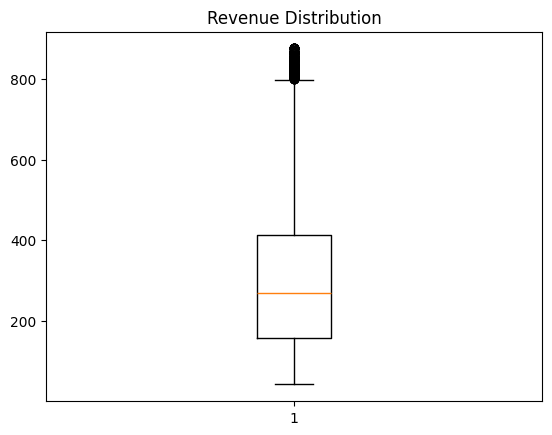

In [ ]:
# 16) Outlier Check (Boxplot)
plt.boxplot(df['revenue_usd'])
plt.title("Revenue Distribution")
plt.show()

In [ ]:
# 17) Encode Ordered Categorical Feature
income_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['customer_income_encoded'] = df['customer_income_level'].map(income_map)

In [ ]:
# 18) Correlation Analysis
df[['base_price_usd', 'discount_percent', 'units_sold',
    'revenue_usd', 'customer_income_encoded', 'customer_rating']].corr()

,base_price_usd,discount_percent,units_sold,revenue_usd,customer_income_encoded,customer_rating
base_price_usd,1.000000,-0.002360,0.005353,0.562852,-0.012214,-0.005461
discount_percent,-0.002360,1.000000,0.005930,-0.187818,0.004353,0.000662
units_sold,0.005353,0.005930,1.000000,0.759549,-0.002095,-0.001177
revenue_usd,0.562852,-0.187818,0.759549,1.000000,-0.008565,-0.003710
customer_income_encoded,-0.012214,0.004353,-0.002095,-0.008565,1.000000,-0.002437
customer_rating,-0.005461,0.000662,-0.001177,-0.003710,-0.002437,1.000000


In [ ]:
# 19) Standardize Column Names
df.columns = df.columns.str.lower().str.strip()

In [ ]:
# 20) Final Dataset Check
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 30000 non-null  object        
 1   order_date               30000 non-null  datetime64[ns]
 2   brand                    30000 non-null  object        
 3   model_name               30000 non-null  object        
 4   category                 30000 non-null  object        
 5   gender                   30000 non-null  object        
 6   size                     30000 non-null  int64         
 7   color                    30000 non-null  object        
 8   base_price_usd           30000 non-null  int64         
 9   discount_percent         30000 non-null  int64         
 10  final_price_usd          30000 non-null  float64       
 11  units_sold               30000 non-null  int64         
 12  revenue_usd              30000 n

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,...,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,year,month,quarter,customer_income_encoded
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,...,137.7,Card,Retail Store,Germany,Low,4.6,2021,1,1,1
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,...,228.0,Card,Online,USA,Low,3.9,2026,10,4,1
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,...,598.4,Cash,Retail Store,India,Medium,3.0,2023,11,4,2
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,...,103.7,Card,Retail Store,India,High,3.4,2026,8,3,3
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,...,320.0,Cash,Online,USA,Medium,3.0,2019,11,4,2
